In [9]:
import pandas as pd
import numpy as np
import warnings, re
import statsmodels.api as sm
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import auc, roc_curve
from matplotlib import pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

In [10]:
df = pd.read_pickle('../data/cleaned_sumo_bouts.pkl')

# Add some features
df['bmi'] = df['weight'] / (df['height']/100)**2
df['opponent_bmi'] = df['opponent_weight'] / (df['opponent_height']/100)**2
df['bmi_diff'] = df['bmi'] - df['opponent_bmi']
df['win_rate_diff'] = df['win_rate_prev6'] - df['opponent_win_rate_prev6']
df.drop(columns=['opponent_bmi', 'opponent_weight', 'opponent_height', 'win_rate_prev6', 'opponent_win_rate_prev6'], inplace=True)

for i in ['height','weight','bmi','height_diff','weight_diff','bmi_diff','age_diff','experience_diff','rank_diff']:
    df[f'{i}_cubed'] = df[i] ** 3

df

,basho,day,bout_id,technique,win,name,heya,shusshin,birth_date,age,...,win_rate_diff,height_cubed,weight_cubed,bmi_cubed,height_diff_cubed,weight_diff_cubed,bmi_diff_cubed,age_diff_cubed,experience_diff_cubed,rank_diff_cubed
16,2015.05,2,45227,hatakikomi,1,Abi,Shikoroyama,Saitama,1994-05-04,21.0,...,-0.052814,6331625.0,1771561.0,44190.176943,343.000,-7762.392,-749.741817,-778.688000,-235.182489,-1.0
17,2015.05,3,45264,sukuinage,0,Abi,Shikoroyama,Saitama,1994-05-04,21.0,...,-0.015261,6331625.0,1771561.0,44190.176943,343.000,-23393.656,-1669.061629,-9.393931,-31.850883,27.0
18,2015.05,4,45295,tsukiotoshi,0,Abi,Shikoroyama,Saitama,1994-05-04,21.0,...,-0.200000,6331625.0,1771561.0,44190.176943,0.125,-23149.125,-628.172820,-54.872000,-369.003371,0.0
19,2015.05,5,45329,uwatenage,1,Abi,Shikoroyama,Saitama,1994-05-04,21.0,...,0.103030,6331625.0,1771561.0,44190.176943,64.000,-6859.000,-401.859878,-912.673000,-2287.103075,-1.0
20,2015.05,6,45365,hatakikomi,1,Abi,Shikoroyama,Saitama,1994-05-04,21.0,...,0.032456,6331625.0,1771561.0,44190.176943,8.000,-137388.096,-4239.759170,-704.969000,-151.781647,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151519,2022.11,11,67538,yorikiri,0,Yutakayama,Tokitsukaze,Niigata,1993-09-22,29.1,...,-0.090936,6331625.0,5639752.0,140679.117904,-125.000,-8000.000,-22.879212,0.125000,1.000000,1.0
151520,2022.11,12,67572,yorikiri,0,Yutakayama,Tokitsukaze,Niigata,1993-09-22,29.1,...,-0.055051,6331625.0,5639752.0,140679.117904,1.000,-10648.000,-352.637783,-10.648000,-10.139176,1.0
151521,2022.11,13,67605,yorikiri,1,Yutakayama,Tokitsukaze,Niigata,1993-09-22,29.1,...,-0.055556,6331625.0,5639752.0,140679.117904,8.000,-1331.000,-86.801571,-357.911000,-368.158325,-512.0
151522,2022.11,14,67640,yorikiri,0,Yutakayama,Tokitsukaze,Niigata,1993-09-22,29.1,...,-0.043295,6331625.0,5639752.0,140679.117904,1000.000,6859.000,0.000739,17.576000,-64.131597,-729.0


In [11]:
y = df['win']
X = df[[
    'win_rate_diff',
    'division',
    'age_diff', 'age_diff_cubed', 
    'height_diff','height_diff_cubed',
    'weight_diff','weight_diff_cubed',
    'experience_diff','experience_diff_cubed',
    'rank_diff','rank_diff_cubed',
    'bmi_diff','bmi_diff_cubed',
    'flag_higher_division','flag_lower_division','flag_same_hometown', 
    'flag_first_day','flag_last_day', 
    'day'
]]

X=pd.get_dummies(X, columns=['division'], drop_first=True)*1
X

,win_rate_diff,age_diff,age_diff_cubed,height_diff,height_diff_cubed,weight_diff,weight_diff_cubed,experience_diff,experience_diff_cubed,rank_diff,...,bmi_diff,bmi_diff_cubed,flag_higher_division,flag_lower_division,flag_same_hometown,flag_first_day,flag_last_day,day,division_Maegashira,division_Makushita
16,-0.052814,-9.20,-778.688000,7.0,343.000,-19.8,-7762.392,-6.172603,-235.182489,-1.0,...,-9.084560,-749.741817,0,0,0,0,0,2,0,0
17,-0.015261,-2.11,-9.393931,7.0,343.000,-28.6,-23393.656,-3.169863,-31.850883,3.0,...,-11.861987,-1669.061629,0,0,0,0,0,3,0,0
18,-0.200000,-3.80,-54.872000,0.5,0.125,-28.5,-23149.125,-7.172603,-369.003371,0.0,...,-8.564323,-628.172820,0,0,0,0,0,4,0,0
19,0.103030,-9.70,-912.673000,4.0,64.000,-19.0,-6859.000,-13.175342,-2287.103075,-1.0,...,-7.379465,-401.859878,0,0,0,0,0,5,0,0
20,0.032456,-8.90,-704.969000,2.0,8.000,-51.6,-137388.096,-5.334247,-151.781647,2.0,...,-16.185038,-4239.759170,0,0,0,0,0,6,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151519,-0.090936,0.50,0.125000,-5.0,-125.000,-20.0,-8000.000,1.000000,1.000000,1.0,...,-2.838880,-22.879212,0,0,0,0,0,11,0,0
151520,-0.055051,-2.20,-10.648000,1.0,1.000,-22.0,-10648.000,-2.164384,-10.139176,1.0,...,-7.064958,-352.637783,0,0,0,0,0,12,0,0
151521,-0.055556,-7.10,-357.911000,2.0,8.000,-11.0,-1331.000,-7.167123,-368.158325,-8.0,...,-4.427676,-86.801571,0,0,0,0,0,13,0,0
151522,-0.043295,2.60,17.576000,10.0,1000.000,19.0,6859.000,-4.002740,-64.131597,-9.0,...,0.090398,0.000739,0,0,0,0,0,14,0,0


In [12]:
np.exp(0.5*1.0316)

np.float64(1.6749779483061338)

In [13]:
b = 0.5
a = np.exp(b*1.0316)
print(a/(1+a))

0.6261651425451091


In [14]:
# Try a logit model
X = sm.add_constant(X)
model = sm.Logit(y, X)
result = model.fit()

# Export to txt file
with open('../output/logit_model_summary.txt', 'w') as f:
    f.write(result.summary().as_text())

Optimization terminated successfully.
         Current function value: 0.675960
         Iterations 5


In [15]:
# New dataset with more features for ML model
y = df['win']
X = df[[
    'win_rate_diff',
    'age_diff', 'age_diff_cubed', 
    'height_diff','height_diff_cubed',
    'weight_diff','weight_diff_cubed',
    'experience_diff','experience_diff_cubed',
    'rank_diff','rank_diff_cubed',
    'bmi_diff','bmi_diff_cubed',
    'flag_higher_division','flag_lower_division','flag_same_hometown', 
    'flag_first_day','flag_last_day', 
    'day', 'heya', 'shusshin', 'division', 'opponent_division'
]]

cats = ['day', 'heya', 'shusshin', 'division', 'opponent_division']

In [16]:
# Create training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=1234, shuffle=True)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((131592, 23), (14622, 23), (131592,), (14622,))

In [17]:
# Try a gradient boosting model
gbc = HistGradientBoostingClassifier(
    categorical_features=cats,
    learning_rate=0.01, 
    max_iter=10000, 
    max_leaf_nodes=None, 
    max_depth=None, 
    min_samples_leaf=40, 
    l2_regularization=1.0, 
    max_features=0.5, 
    early_stopping=True, 
    scoring='f1', 
    n_iter_no_change=20, 
    verbose=2, 
    random_state=1234
)

gbc.fit(X_train, y_train, X_val=X_test, y_val=y_test)

Binning 0.024 GB of training data: 0.044 s
Binning 0.003 GB of validation data: 0.002 s
Fitting gradient boosted rounds:
[1/10000] 1 tree, 2416 leaves, max depth = 26, train score: 0.61540, val score: 0.50582, in 0.208s
[2/10000] 1 tree, 2428 leaves, max depth = 26, train score: 0.67444, val score: 0.52418, in 0.277s
[3/10000] 1 tree, 2426 leaves, max depth = 22, train score: 0.69815, val score: 0.53460, in 0.196s
[4/10000] 1 tree, 2411 leaves, max depth = 23, train score: 0.71526, val score: 0.54084, in 0.198s
[5/10000] 1 tree, 2407 leaves, max depth = 22, train score: 0.72666, val score: 0.54261, in 0.206s
[6/10000] 1 tree, 2418 leaves, max depth = 24, train score: 0.73107, val score: 0.54487, in 0.197s
[7/10000] 1 tree, 2415 leaves, max depth = 23, train score: 0.73834, val score: 0.55219, in 0.190s
[8/10000] 1 tree, 2435 leaves, max depth = 23, train score: 0.74127, val score: 0.55262, in 0.205s
[9/10000] 1 tree, 2433 leaves, max depth = 23, train score: 0.74671, val score: 0.55530

,loss,'log_loss'
,learning_rate,0.01
,max_iter,10000
,max_leaf_nodes,None
,max_depth,None
,min_samples_leaf,40
,l2_regularization,1.0
,max_features,0.5
,max_bins,255
,categorical_features,"['day', 'heya', ...]"
,monotonic_cst,None


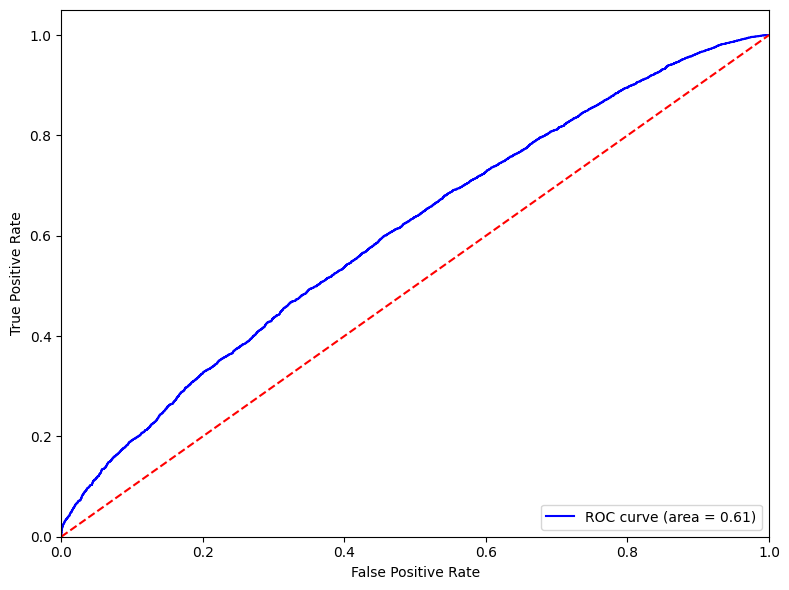

In [18]:
# Plot ROC curve on test set
y_scores = gbc.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../output/roc_curve_bout_level_model.pdf')
plt.show()